In [5]:
# ==========================================================
# Hybrid AI-Based Risk Assessment Engine
# Intelligent Flight Operations Analytics
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

plt.style.use("ggplot")

print("="*70)
print("Hybrid AI-Based Risk Assessment Engine")
print("="*70)

Hybrid AI-Based Risk Assessment Engine


In [6]:
# ==========================================================
# Load Datasets
# ==========================================================

elm_df = pd.read_csv("../data/final/elm_anomaly_detection_dataset.csv")

weather_df = pd.read_csv("../data/final/weather_cross_dataset_feature_engineered.csv")

delay_df = pd.read_csv("../data/final/delay_cross_dataset_feature_engineered.csv")

In [7]:
print("ELM Dataset Shape :", elm_df.shape)
print("Weather Dataset Shape :", weather_df.shape)
print("Delay Dataset Shape :", delay_df.shape)

ELM Dataset Shape : (7516, 89)
Weather Dataset Shape : (1629108, 21)
Delay Dataset Shape : (3000000, 44)


In [8]:
print("="*60)
print("ELM DATASET")
print("="*60)

display(elm_df.head())

print(elm_df.shape)

ELM DATASET


,icao24,callsign,origin_country,time_position,last_constant,longitude,latitude,baro_altitude,on_ground,velocity,...,Smart_Alert_Priority,Information_Filter_Level,Decision_Support_Recommendation,GMM_Cluster,GMM_Log_Likelihood,GMM_Anomaly_Score,GMM_Anomaly_Label,ELM_Reconstruction_Error,ELM_Anomaly_Score,ELM_Anomaly_Label
0,80162D,AXB848,India,1.767745e+09,1767745048,52.7391,25.4425,9608.82,False,257.34,...,Low,Background Monitoring,Background Monitoring,0,-0.413259,24.597643,Normal,0.026762,0.026762,Normal
1,AE1FA0,72209,United States,1.767745e+09,1767745047,-84.9380,38.1463,571.50,False,73.38,...,Medium,Standard Monitoring,Routine Monitoring,9,10.915888,13.268496,Normal,0.001748,0.001748,Normal
2,AC96B8,AAL1175,United States,1.767745e+09,1767745048,-102.0238,34.0962,10363.20,False,196.90,...,Medium,Standard Monitoring,Routine Monitoring,7,14.991280,9.193104,Normal,0.001536,0.001536,Normal
3,C81BD3,ZKAMK,New Zealand,1.767745e+09,1767744917,174.5408,-35.8060,624.84,False,56.90,...,Medium,Standard Monitoring,Routine Monitoring,15,2.057020,22.127363,Normal,0.008986,0.008986,Normal
4,AA56DB,UAL2447,United States,1.767745e+09,1767745048,-102.7402,37.4696,10972.80,False,200.08,...,Medium,Standard Monitoring,Routine Monitoring,7,14.705517,9.478866,Normal,0.001448,0.001448,Normal


(7516, 89)


In [9]:
print("="*60)
print("WEATHER DATASET")
print("="*60)

display(weather_df.head())

print(weather_df.shape)

WEATHER DATASET


,datetime,city,temperature,humidity,pressure,wind_direction,weather_description,temperature_category,humidity_category,pressure_category,...,rain_indicator,snow_indicator,storm_indicator,fog_indicator,cloud_category,weather_severity,weather_risk_score,Weather_Operational_Severity,Weather_Disruption_Level,Weather_Alert_Priority
0,2012-10-01 12:00:00,Albuquerque,11.970000,50.0,1024.0,360.0,sky is clear,Cool,Medium,Normal,...,0,0,0,0,Clear,Low,1,Low,Minimal,Routine
1,2012-10-01 13:00:00,Albuquerque,11.970000,50.0,1024.0,360.0,sky is clear,Cool,Medium,Normal,...,0,0,0,0,Clear,Low,1,Low,Minimal,Routine
2,2012-10-01 14:00:00,Albuquerque,12.004558,49.0,1024.0,360.0,sky is clear,Cool,Medium,Normal,...,0,0,0,0,Clear,Low,1,Low,Minimal,Routine
3,2012-10-01 15:00:00,Albuquerque,12.083952,49.0,1024.0,360.0,sky is clear,Cool,Medium,Normal,...,0,0,0,0,Clear,Low,1,Low,Minimal,Routine
4,2012-10-01 16:00:00,Albuquerque,12.163345,49.0,1024.0,360.0,sky is clear,Cool,Medium,Normal,...,0,0,0,0,Clear,Low,1,Low,Minimal,Routine


(1629108, 21)


In [10]:
print("="*60)
print("DELAY DATASET")
print("="*60)

display(delay_df.head())

print(delay_df.shape)

DELAY DATASET


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DELAY_CATEGORY,FLIGHT_PERFORMANCE_INDEX,OPERATIONAL_DISRUPTION,AIRLINE_RELIABILITY,AIRPORT_DELAY_CATEGORY,SEASON,TIME_OF_DAY,Delay_Operational_Severity,Airline_Reliability_Profile,Delay_Alert_Priority
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,Early,100.0,0,Medium,Medium Delay,Winter,Morning,Low,Average,Routine
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,On Time,100.0,0,High,Medium Delay,Autumn,Night,Low,Reliable,Routine
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,On Time,100.0,0,Medium,Medium Delay,Summer,Morning,Low,Average,Routine
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,Delayed,76.0,0,High,Medium Delay,Spring,Afternoon,Medium,Reliable,Monitor
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,On Time,100.0,0,Medium,Medium Delay,Winter,Evening,Low,Average,Routine


(3000000, 44)


In [11]:
print("="*60)
print("Missing Values")
print("="*60)

print("\nELM")
print(elm_df.isnull().sum().sort_values(ascending=False).head(10))

print("\nWeather")
print(weather_df.isnull().sum().sort_values(ascending=False).head(10))

print("\nDelay")
print(delay_df.isnull().sum().sort_values(ascending=False).head(10))

Missing Values

ELM
squawk             4286
Aircraft_Age       3255
YEAR MFR           3255
ENG MFR MDL        3201
AIR WORTH DATE     3201
CERTIFICATION      3189
EXPIRATION DATE    3055
CERT ISSUE DATE    3055
SERIAL NUMBER      3049
TYPE REGISTRANT    3049
dtype: int64

Weather
pressure_category       2
city                    0
temperature             0
humidity                0
datetime                0
pressure                0
wind_direction          0
temperature_category    0
weather_description     0
humidity_category       0
dtype: int64

Delay
CANCELLATION_CODE    2920860
AIR_TIME               86198
ARR_DELAY              86198
ELAPSED_TIME           86198
WHEELS_ON              79944
TAXI_IN                79944
ARR_TIME               79942
TAXI_OUT               78806
WHEELS_OFF             78806
DEP_DELAY              77644
dtype: int64


In [12]:
behaviour_df = elm_df[[
    "GMM_Anomaly_Score",
    "ELM_Anomaly_Score",
    "Operational_Complexity_Index",
    "Airport_Operational_Profile",
    "Aircraft_Operational_Capability"
]].copy()

In [13]:
behaviour_df.head()

,GMM_Anomaly_Score,ELM_Anomaly_Score,Operational_Complexity_Index,Airport_Operational_Profile,Aircraft_Operational_Capability
0,24.597643,0.026762,7,Local Airport,Unknown
1,13.268496,0.001748,6,Local Airport,Unknown
2,9.193104,0.001536,8,Local Airport,High Capability
3,22.127363,0.008986,6,Local Airport,Unknown
4,9.478866,0.001448,8,Local Airport,High Capability


In [14]:
behaviour_df.describe().T

,count,mean,std,min,25%,50%,75%,max
GMM_Anomaly_Score,7516.0,17.964940,7.468599,0.000000,12.303949,18.169104,24.128063,46.442023
ELM_Anomaly_Score,7516.0,0.017461,0.040174,0.000329,0.004562,0.009046,0.019274,1.670845
Operational_Complexity_Index,7516.0,6.912986,1.325681,4.000000,6.000000,7.000000,8.000000,11.000000


In [15]:
scaler = MinMaxScaler()

behaviour_df[[
    "GMM_Anomaly_Score",
    "ELM_Anomaly_Score",
    "Operational_Complexity_Index"
]] = scaler.fit_transform(

    behaviour_df[[
        "GMM_Anomaly_Score",
        "ELM_Anomaly_Score",
        "Operational_Complexity_Index"
    ]]
)

In [16]:
elm_df["Airport_Operational_Profile"].value_counts()

Airport_Operational_Profile
Local Airport    6374
Major Hub         854
Regional Hub      288
Name: count, dtype: int64

In [17]:
airport_map = {

    "Local Airport": 1,

    "Regional Hub": 2,

    "Major Hub": 3

}

In [18]:
elm_df["Aircraft_Operational_Capability"].value_counts()

Aircraft_Operational_Capability
Unknown                3049
High Capability        2070
Light Capability       1616
Medium Capability       758
Standard Capability      23
Name: count, dtype: int64

In [19]:
aircraft_map = {

    "Unknown": 0,

    "Light Capability": 1,

    "Medium Capability": 2,

    "Standard Capability": 3,

    "High Capability": 4

}

In [20]:
behaviour_df["Airport_Profile_Score"] = (
    elm_df["Airport_Operational_Profile"]
    .map(airport_map)
)

behaviour_df["Aircraft_Capability_Score"] = (
    elm_df["Aircraft_Operational_Capability"]
    .map(aircraft_map)
)

In [21]:
behaviour_df[
    [
        "Airport_Profile_Score",
        "Aircraft_Capability_Score"
    ]
] = scaler.fit_transform(

    behaviour_df[
        [
            "Airport_Profile_Score",
            "Aircraft_Capability_Score"
        ]
    ]
)

In [22]:
behaviour_df["Behavioural_Intelligence_Score"] = (

      behaviour_df["GMM_Anomaly_Score"] * 0.30

    + behaviour_df["ELM_Anomaly_Score"] * 0.30

    + behaviour_df["Operational_Complexity_Index"] * 0.20

    + behaviour_df["Airport_Profile_Score"] * 0.10

    + behaviour_df["Aircraft_Capability_Score"] * 0.10

)

In [58]:
elm_df["Behavioural_Intelligence_Score"] = (
    behaviour_df["Behavioural_Intelligence_Score"]
)

In [59]:
print(elm_df[["Behavioural_Intelligence_Score"]].head())

   Behavioural_Intelligence_Score
0                        0.249354
1                        0.143108
2                        0.273887
3                        0.201633
4                        0.275717


In [23]:
behaviour_df["Behavioural_Intelligence_Score"].describe()

count    7516.000000
mean        0.253819
std         0.088786
min         0.050735
25%         0.175581
50%         0.251577
75%         0.298672
max         0.630520
Name: Behavioural_Intelligence_Score, dtype: float64

In [24]:
elm_df["Airport_Operational_Profile"].value_counts()

elm_df["Aircraft_Operational_Capability"].value_counts()

Aircraft_Operational_Capability
Unknown                3049
High Capability        2070
Light Capability       1616
Medium Capability       758
Standard Capability      23
Name: count, dtype: int64

In [25]:
# ==========================================================
# Weather Intelligence Module
# ==========================================================

print("=" * 70)
print("Weather Intelligence Module")
print("=" * 70)

print("\nColumns")
print(weather_df.columns.tolist())

Weather Intelligence Module

Columns
['datetime', 'city', 'temperature', 'humidity', 'pressure', 'wind_direction', 'weather_description', 'temperature_category', 'humidity_category', 'pressure_category', 'wind_direction_category', 'rain_indicator', 'snow_indicator', 'storm_indicator', 'fog_indicator', 'cloud_category', 'weather_severity', 'weather_risk_score', 'Weather_Operational_Severity', 'Weather_Disruption_Level', 'Weather_Alert_Priority']


In [26]:
weather_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
datetime,1629108,45253,2012-10-01 12:00:00,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,1629108,36,Albuquerque,45253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temperature,1629108.0,NaN,NaN,NaN,15.470303,10.340225,-30.813333,8.78,16.451349,23.12,48.07
humidity,1629108.0,NaN,NaN,NaN,68.012713,22.513886,5.0,53.0,71.0,87.0,100.0
pressure,1629108.0,NaN,NaN,NaN,1016.48918,15.649905,800.0,1012.0,1017.0,1024.0,1100.0
wind_direction,1629108.0,NaN,NaN,NaN,182.521635,106.248609,0.0,93.0,190.0,270.0,360.0
weather_description,1629108,54,sky is clear,655203,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temperature_category,1629108,4,Moderate,808287,NaN,NaN,NaN,NaN,NaN,NaN,NaN
humidity_category,1629108,3,High,833140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pressure_category,1629106,3,Normal,1141193,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
weather_df.columns.tolist()

['datetime',
 'city',
 'temperature',
 'humidity',
 'pressure',
 'wind_direction',
 'weather_description',
 'temperature_category',
 'humidity_category',
 'pressure_category',
 'wind_direction_category',
 'rain_indicator',
 'snow_indicator',
 'storm_indicator',
 'fog_indicator',
 'cloud_category',
 'weather_severity',
 'weather_risk_score',
 'Weather_Operational_Severity',
 'Weather_Disruption_Level',
 'Weather_Alert_Priority']

In [28]:
[col for col in weather_df.columns if "Weather" in col]

['Weather_Operational_Severity',
 'Weather_Disruption_Level',
 'Weather_Alert_Priority']

In [29]:
[col for col in weather_df.columns if "Risk" in col]

[]

In [30]:
[col for col in weather_df.columns if "Priority" in col]

['Weather_Alert_Priority']

Weather Severity Distribution
Weather_Operational_Severity
Low       1596466
Medium      30380
High         2262
Name: count, dtype: int64


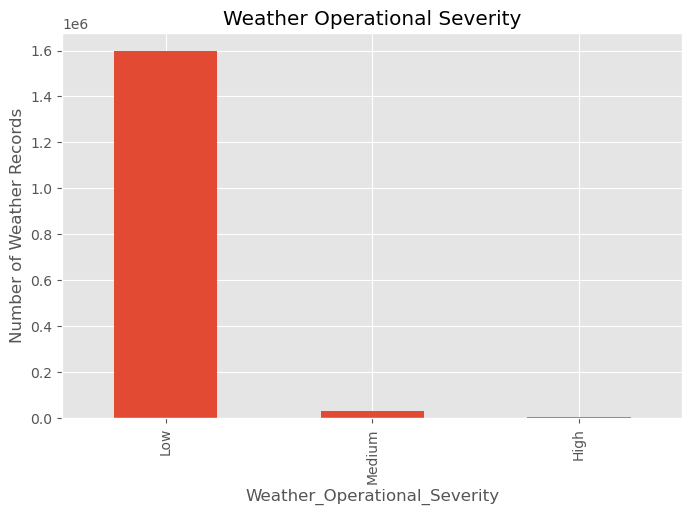

In [31]:
# ==========================================================
# Weather Severity Distribution
# ==========================================================

print("="*70)
print("Weather Severity Distribution")
print("="*70)

weather_severity = weather_df["Weather_Operational_Severity"].value_counts()

print(weather_severity)

plt.figure(figsize=(8,5))

weather_severity.plot(
    kind="bar"
)

plt.title("Weather Operational Severity")

plt.ylabel("Number of Weather Records")

plt.show()

Weather Alert Priority Distribution
Weather_Alert_Priority
Routine      1250396
Monitor       364053
Immediate      14659
Name: count, dtype: int64


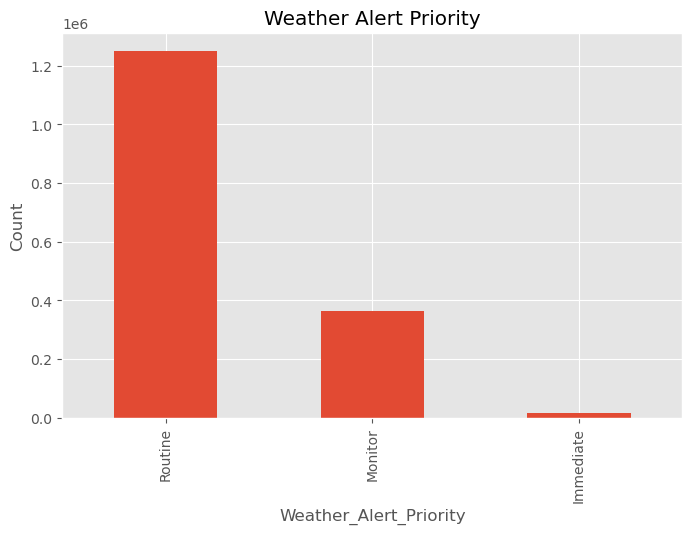

In [32]:
print("="*70)
print("Weather Alert Priority Distribution")
print("="*70)

weather_alert = weather_df["Weather_Alert_Priority"].value_counts()

print(weather_alert)

plt.figure(figsize=(8,5))

weather_alert.plot(
    kind="bar"
)

plt.title("Weather Alert Priority")

plt.ylabel("Count")

plt.show()

Weather Disruption Level
Weather_Disruption_Level
Minimal     1250396
Moderate     364053
Severe        14659
Name: count, dtype: int64


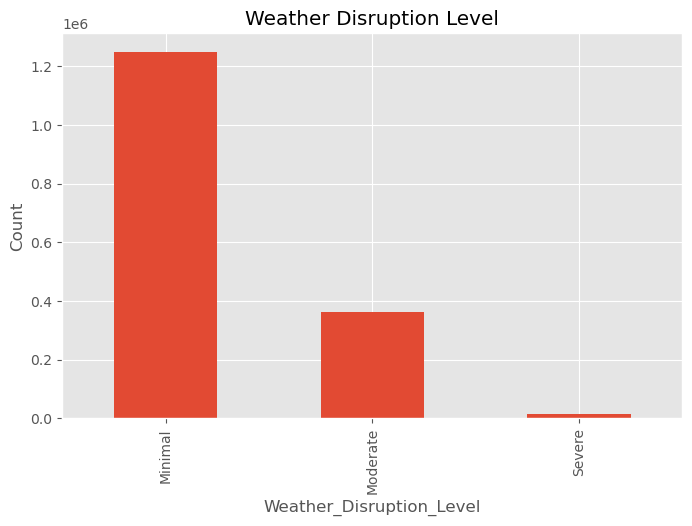

In [33]:
print("="*70)
print("Weather Disruption Level")
print("="*70)

weather_disruption = weather_df["Weather_Disruption_Level"].value_counts()

print(weather_disruption)

plt.figure(figsize=(8,5))

weather_disruption.plot(
    kind="bar"
)

plt.title("Weather Disruption Level")

plt.ylabel("Count")

plt.show()

In [34]:
print("="*70)
print("Weather Risk Score Statistics")
print("="*70)

weather_df["weather_risk_score"].describe()

Weather Risk Score Statistics


count    1.629108e+06
mean     1.241464e+00
std      4.485038e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.000000e+00
Name: weather_risk_score, dtype: float64

In [35]:
weather_intelligence_score = (

    weather_df["weather_risk_score"].mean()

)

In [36]:
print("="*70)

print("Weather Intelligence Score")

print("="*70)

print(round(weather_intelligence_score,3))

Weather Intelligence Score
1.241


In [37]:
weather_intelligence_score = weather_intelligence_score / 3

print(weather_intelligence_score)

0.41382134681473953


In [38]:
# ==========================================================
# Weather Intelligence Summary
# ==========================================================

weather_summary = {

    "Average_Weather_Risk": weather_df["weather_risk_score"].mean(),

    "High_Severity_Percentage":
        (weather_df["Weather_Operational_Severity"] == "High").mean() * 100,

    "Immediate_Alert_Percentage":
        (weather_df["Weather_Alert_Priority"] == "Immediate").mean() * 100,

    "Severe_Disruption_Percentage":
        (weather_df["Weather_Disruption_Level"] == "Severe").mean() * 100

}

weather_summary = pd.DataFrame(
    weather_summary,
    index=["Weather Intelligence"]
)

weather_summary

,Average_Weather_Risk,High_Severity_Percentage,Immediate_Alert_Percentage,Severe_Disruption_Percentage
Weather Intelligence,1.241464,0.138849,0.899818,0.899818


In [39]:
# ==========================================================
# Delay Intelligence Module
# ==========================================================

print("="*70)
print("Delay Intelligence Module")
print("="*70)

print("\nColumns")

print(delay_df.columns.tolist())

Delay Intelligence Module

Columns
['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE', 'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT', 'TOTAL_DELAY', 'DELAY_SEVERITY', 'DELAY_CATEGORY', 'FLIGHT_PERFORMANCE_INDEX', 'OPERATIONAL_DISRUPTION', 'AIRLINE_RELIABILITY', 'AIRPORT_DELAY_CATEGORY', 'SEASON', 'TIME_OF_DAY', 'Delay_Operational_Severity', 'Airline_Reliability_Profile', 'Delay_Alert_Priority']


In [40]:
delay_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
FL_DATE,3000000,1704,2019-07-25,2379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AIRLINE,3000000,18,Southwest Airlines Co.,576470,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AIRLINE_DOT,3000000,18,Southwest Airlines Co.: WN,576470,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AIRLINE_CODE,3000000,18,WN,576470,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DOT_CODE,3000000.0,NaN,NaN,NaN,19976.294095,377.284619,19393.0,19790.0,19930.0,20368.0,20452.0
FL_NUMBER,3000000.0,NaN,NaN,NaN,2511.535519,1747.25804,1.0,1051.0,2152.0,3797.0,9562.0
ORIGIN,3000000,380,ATL,153556,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ORIGIN_CITY,3000000,373,"Chicago, IL",157368,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DEST,3000000,380,ATL,153569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DEST_CITY,3000000,373,"Chicago, IL",158087,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Delay Operational Severity
Delay_Operational_Severity
Low       2398515
Medium     340154
High       261331
Name: count, dtype: int64


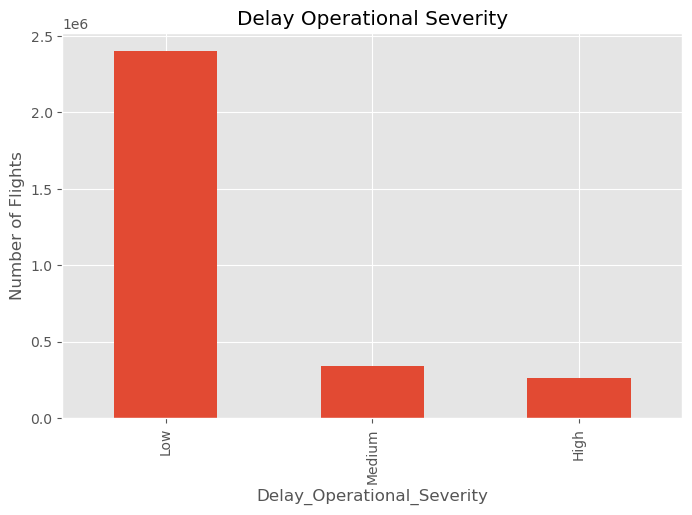

In [41]:
print("="*70)
print("Delay Operational Severity")
print("="*70)

delay_severity = delay_df["Delay_Operational_Severity"].value_counts()

print(delay_severity)

plt.figure(figsize=(8,5))

delay_severity.plot(kind="bar")

plt.title("Delay Operational Severity")

plt.ylabel("Number of Flights")

plt.show()

Airline Reliability Profile
Airline_Reliability_Profile
Reliable    1952537
Average     1047463
Name: count, dtype: int64


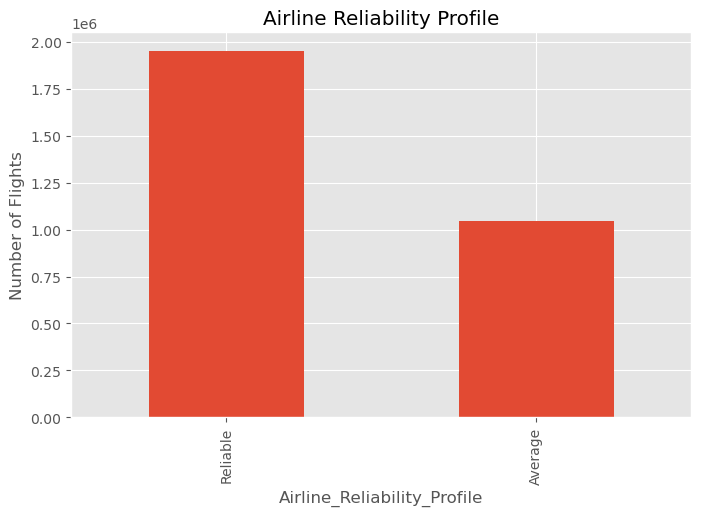

In [42]:
print("="*70)
print("Airline Reliability Profile")
print("="*70)

airline_profile = delay_df["Airline_Reliability_Profile"].value_counts()

print(airline_profile)

plt.figure(figsize=(8,5))

airline_profile.plot(kind="bar")

plt.title("Airline Reliability Profile")

plt.ylabel("Number of Flights")

plt.show()

Delay Alert Priority
Delay_Alert_Priority
Routine      2398515
Monitor       340154
Immediate     261331
Name: count, dtype: int64


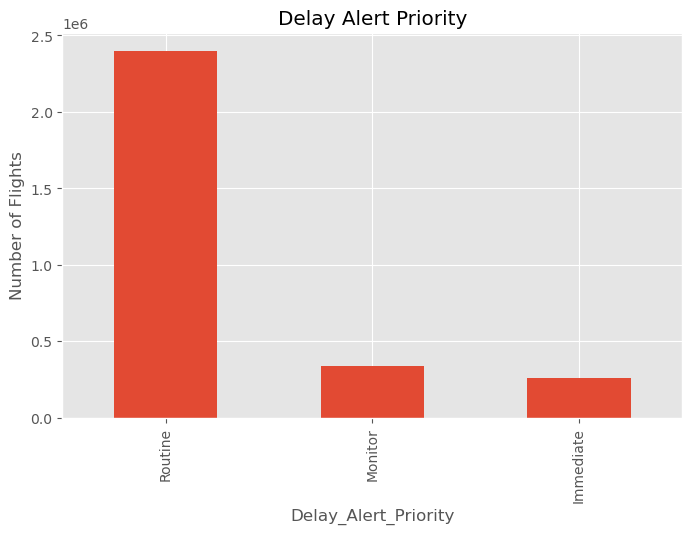

In [43]:
print("="*70)
print("Delay Alert Priority")
print("="*70)

delay_alert = delay_df["Delay_Alert_Priority"].value_counts()

print(delay_alert)

plt.figure(figsize=(8,5))

delay_alert.plot(kind="bar")

plt.title("Delay Alert Priority")

plt.ylabel("Number of Flights")

plt.show()

In [44]:
print("="*70)
print("Flight Performance Index")
print("="*70)

delay_df["FLIGHT_PERFORMANCE_INDEX"].describe()

Flight Performance Index


count    3.000000e+06
mean     9.015237e+01
std      2.282686e+01
min      0.000000e+00
25%      9.400000e+01
50%      1.000000e+02
75%      1.000000e+02
max      1.000000e+02
Name: FLIGHT_PERFORMANCE_INDEX, dtype: float64

In [45]:
delay_severity_map = {

    "Low":1,

    "Medium":2,

    "High":3

}

In [46]:
airline_map = {

    "Reliable":1,

    "Average":2,

    "Poor":3

}

In [47]:
alert_map = {

    "Routine":1,

    "Monitor":2,

    "Immediate":3

}

In [48]:
delay_intelligence = pd.DataFrame()

delay_intelligence["Delay_Severity"] = (

    delay_df["Delay_Operational_Severity"]

    .map(delay_severity_map)

)

delay_intelligence["Airline_Reliability"] = (

    delay_df["Airline_Reliability_Profile"]

    .map(airline_map)

)

delay_intelligence["Delay_Alert"] = (

    delay_df["Delay_Alert_Priority"]

    .map(alert_map)

)

delay_intelligence["Performance"] = (

    delay_df["FLIGHT_PERFORMANCE_INDEX"]

)

In [49]:
scaler = MinMaxScaler()

delay_intelligence = pd.DataFrame(

    scaler.fit_transform(delay_intelligence),

    columns=delay_intelligence.columns

)

In [50]:
delay_intelligence["Delay_Intelligence_Score"] = (

      delay_intelligence["Delay_Severity"]*0.35

    + delay_intelligence["Airline_Reliability"]*0.25

    + delay_intelligence["Delay_Alert"]*0.20

    + delay_intelligence["Performance"]*0.20

)

In [51]:
delay_intelligence["Delay_Intelligence_Score"].describe()

count    3.000000e+06
mean     3.466848e-01
std      1.852723e-01
min      1.700000e-01
25%      2.000000e-01
50%      2.000000e-01
75%      4.500000e-01
max      1.000000e+00
Name: Delay_Intelligence_Score, dtype: float64

In [52]:
delay_score = delay_intelligence["Delay_Intelligence_Score"].mean()

print("="*70)

print("Delay Intelligence Score")

print("="*70)

print(round(delay_score,3))

Delay Intelligence Score
0.347


In [53]:
# ==========================================================
# Operational Intelligence Module
# ==========================================================

print("=" * 70)
print("Operational Intelligence Module")
print("=" * 70)

# Overall operational context score
operational_intelligence_score = (

      weather_intelligence_score * 0.60

    + delay_score * 0.40

)

print(f"Weather Intelligence Score      : {weather_intelligence_score:.3f}")
print(f"Delay Intelligence Score        : {delay_score:.3f}")
print("-" * 50)
print(f"Operational Intelligence Score  : {operational_intelligence_score:.3f}")

Operational Intelligence Module
Weather Intelligence Score      : 0.414
Delay Intelligence Score        : 0.347
--------------------------------------------------
Operational Intelligence Score  : 0.387


In [54]:
operational_summary = pd.DataFrame({

    "Weather Intelligence Score": [weather_intelligence_score],

    "Delay Intelligence Score": [delay_score],

    "Operational Intelligence Score": [operational_intelligence_score]

})

operational_summary

,Weather Intelligence Score,Delay Intelligence Score,Operational Intelligence Score
0,0.413821,0.346685,0.386967


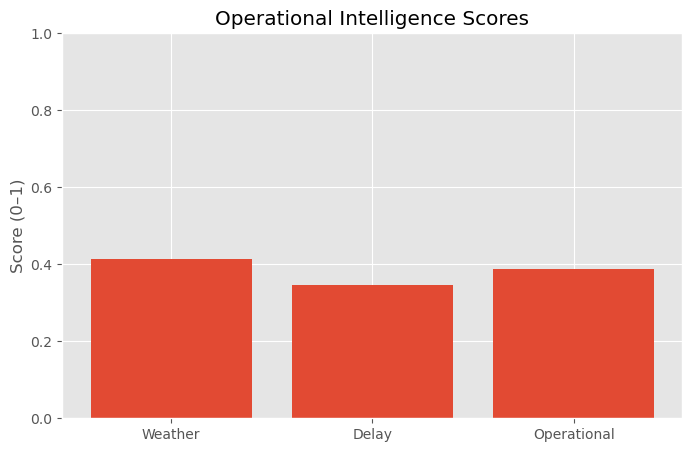

In [55]:
scores = {

    "Weather": weather_intelligence_score,

    "Delay": delay_score,

    "Operational": operational_intelligence_score

}

plt.figure(figsize=(8,5))

plt.bar(scores.keys(), scores.values())

plt.title("Operational Intelligence Scores")

plt.ylabel("Score (0–1)")

plt.ylim(0, 1)

plt.show()

In [60]:
# ==========================================================
# Hybrid AI Risk Assessment Engine
# ==========================================================

print("="*70)
print("Hybrid AI Risk Assessment Engine")
print("="*70)

# ----------------------------------------------------------
# Ensure Behavioural Intelligence Score exists
# ----------------------------------------------------------

if "Behavioural_Intelligence_Score" not in elm_df.columns:

    raise ValueError(
        "Behavioural Intelligence Score not found. "
        "Please complete the Behavioural Intelligence Module first."
    )

# ----------------------------------------------------------
# Add Operational Intelligence Score
# ----------------------------------------------------------

elm_df["Operational_Intelligence_Score"] = operational_intelligence_score

# ----------------------------------------------------------
# Calculate Raw Hybrid Risk
# ----------------------------------------------------------

elm_df["Hybrid_Raw_Risk"] = (

      elm_df["Behavioural_Intelligence_Score"] * 0.70

    + elm_df["Operational_Intelligence_Score"] * 0.30

)

print()

print("Raw Hybrid Risk Created Successfully")

print()

display(elm_df[[
    "Behavioural_Intelligence_Score",
    "Operational_Intelligence_Score",
    "Hybrid_Raw_Risk"
]].head())

Hybrid AI Risk Assessment Engine

Raw Hybrid Risk Created Successfully



,Behavioural_Intelligence_Score,Operational_Intelligence_Score,Hybrid_Raw_Risk
0,0.249354,0.386967,0.290638
1,0.143108,0.386967,0.216265
2,0.273887,0.386967,0.307811
3,0.201633,0.386967,0.257233
4,0.275717,0.386967,0.309092


In [61]:
print("="*70)
print("Hybrid Raw Risk Statistics")
print("="*70)

display(

elm_df["Hybrid_Raw_Risk"].describe()

)

Hybrid Raw Risk Statistics


count    7516.000000
mean        0.293763
std         0.062150
min         0.151604
25%         0.238997
50%         0.292194
75%         0.325161
max         0.557454
Name: Hybrid_Raw_Risk, dtype: float64

In [62]:
from sklearn.preprocessing import MinMaxScaler

risk_scaler = MinMaxScaler(feature_range=(0,100))

elm_df["Hybrid_Flight_Risk_Score"] = (

risk_scaler.fit_transform(

elm_df[["Hybrid_Raw_Risk"]]

)

)

print("="*70)
print("Hybrid Flight Risk Score Created")
print("="*70)

display(

elm_df["Hybrid_Flight_Risk_Score"].describe()

)

Hybrid Flight Risk Score Created


count    7516.000000
mean       35.027511
std        15.313560
min         0.000000
25%        21.533203
50%        34.640716
75%        42.763668
max       100.000000
Name: Hybrid_Flight_Risk_Score, dtype: float64

In [63]:
def classify_risk(score):

    if score < 25:

        return "Low"

    elif score < 50:

        return "Medium"

    elif score < 75:

        return "High"

    else:

        return "Critical"


elm_df["Hybrid_Risk_Category"] = (

elm_df["Hybrid_Flight_Risk_Score"]

.apply(classify_risk)

)

In [64]:
print("="*70)
print("Hybrid Risk Distribution")
print("="*70)

print(

elm_df["Hybrid_Risk_Category"]

.value_counts()

)

Hybrid Risk Distribution
Hybrid_Risk_Category
Medium      3841
Low         2311
High        1298
Critical      66
Name: count, dtype: int64


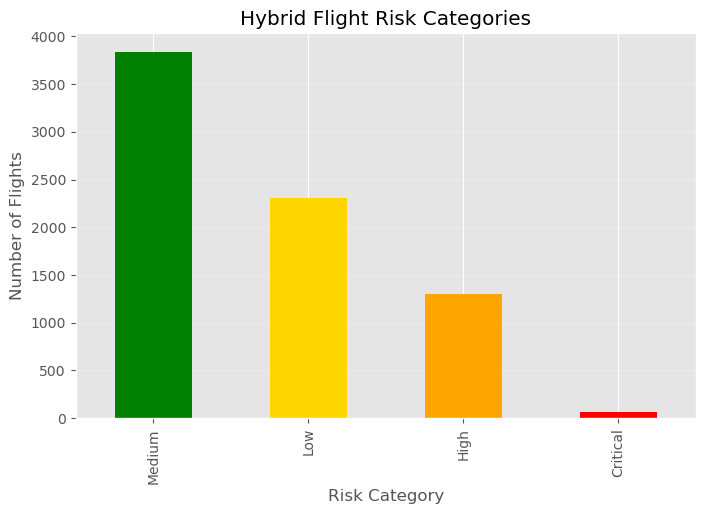

In [65]:
plt.figure(figsize=(8,5))

elm_df["Hybrid_Risk_Category"].value_counts().plot(

kind="bar",

color=["green","gold","orange","red"]

)

plt.title("Hybrid Flight Risk Categories")

plt.xlabel("Risk Category")

plt.ylabel("Number of Flights")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [66]:
display(

elm_df[[
    "Behavioural_Intelligence_Score",
    "Operational_Intelligence_Score",
    "Hybrid_Raw_Risk",
    "Hybrid_Flight_Risk_Score",
    "Hybrid_Risk_Category"
]].head()

)

,Behavioural_Intelligence_Score,Operational_Intelligence_Score,Hybrid_Raw_Risk,Hybrid_Flight_Risk_Score,Hybrid_Risk_Category
0,0.249354,0.386967,0.290638,34.257313,Medium
1,0.143108,0.386967,0.216265,15.932230,Low
2,0.273887,0.386967,0.307811,38.488734,Medium
3,0.201633,0.386967,0.257233,26.026544,Medium
4,0.275717,0.386967,0.309092,38.804378,Medium


In [67]:
# ==========================================================
# Normalize Hybrid Risk Score (0–100)
# ==========================================================

from sklearn.preprocessing import MinMaxScaler

risk_scaler = MinMaxScaler(feature_range=(0, 100))

elm_df["Hybrid_Flight_Risk_Score"] = risk_scaler.fit_transform(
    elm_df[["Hybrid_Raw_Risk"]]
)

print("="*70)
print("Hybrid Flight Risk Score Created Successfully")
print("="*70)

display(
    elm_df[
        [
            "Hybrid_Raw_Risk",
            "Hybrid_Flight_Risk_Score"
        ]
    ].head()
)

print()
print(elm_df["Hybrid_Flight_Risk_Score"].describe())

Hybrid Flight Risk Score Created Successfully


,Hybrid_Raw_Risk,Hybrid_Flight_Risk_Score
0,0.290638,34.257313
1,0.216265,15.932230
2,0.307811,38.488734
3,0.257233,26.026544
4,0.309092,38.804378



count    7516.000000
mean       35.027511
std        15.313560
min         0.000000
25%        21.533203
50%        34.640716
75%        42.763668
max       100.000000
Name: Hybrid_Flight_Risk_Score, dtype: float64


In [68]:
# ==========================================================
# SECTION 10 - Hybrid Flight Risk Categorization
# ==========================================================

print("="*70)
print("Hybrid Flight Risk Categorization")
print("="*70)

def classify_hybrid_risk(score):

    if score < 25:
        return "Low"

    elif score < 50:
        return "Medium"

    elif score < 75:
        return "High"

    else:
        return "Critical"


elm_df["Hybrid_Risk_Category"] = (
    elm_df["Hybrid_Flight_Risk_Score"]
    .apply(classify_hybrid_risk)
)

print("Risk Categories Created Successfully")

Hybrid Flight Risk Categorization
Risk Categories Created Successfully


In [75]:
# ==========================================================
# Arrange Risk Categories in Logical Order
# ==========================================================

order = ["Low", "Medium", "High", "Critical"]

elm_df["Hybrid_Risk_Category"] = pd.Categorical(
    elm_df["Hybrid_Risk_Category"],
    categories=order,
    ordered=True
)

In [76]:
print("="*70)
print("Hybrid Risk Category Distribution")
print("="*70)

risk_distribution = (
    elm_df["Hybrid_Risk_Category"]
    .value_counts()
)

print(risk_distribution)

Hybrid Risk Category Distribution
Hybrid_Risk_Category
Medium      3841
Low         2311
High        1298
Critical      66
Name: count, dtype: int64


In [77]:
print("="*70)
print("Percentage Distribution")
print("="*70)

risk_percentage = (
    elm_df["Hybrid_Risk_Category"]
    .value_counts(normalize=True)
    * 100
)

print(risk_percentage.round(2))

Percentage Distribution
Hybrid_Risk_Category
Medium      51.10
Low         30.75
High        17.27
Critical     0.88
Name: proportion, dtype: float64


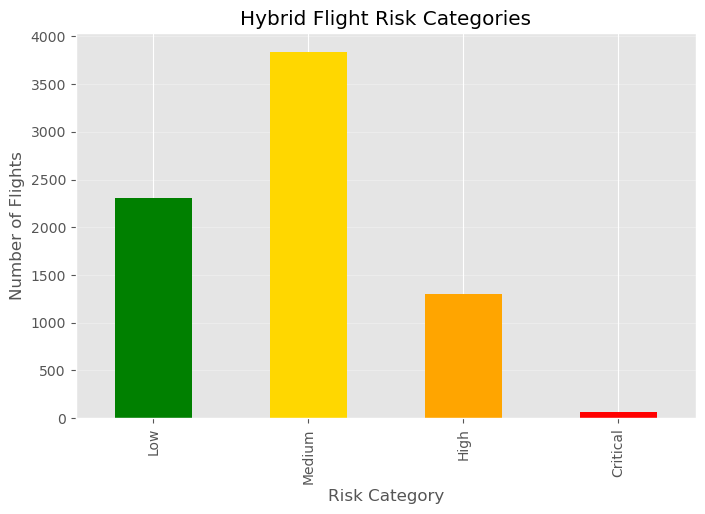

In [78]:
plt.figure(figsize=(8,5))

elm_df["Hybrid_Risk_Category"].value_counts().sort_index().plot(
    kind="bar",
    color=["green", "gold", "orange", "red"]
)

plt.title("Hybrid Flight Risk Categories")

plt.xlabel("Risk Category")

plt.ylabel("Number of Flights")

plt.grid(axis="y", alpha=0.3)

plt.show()

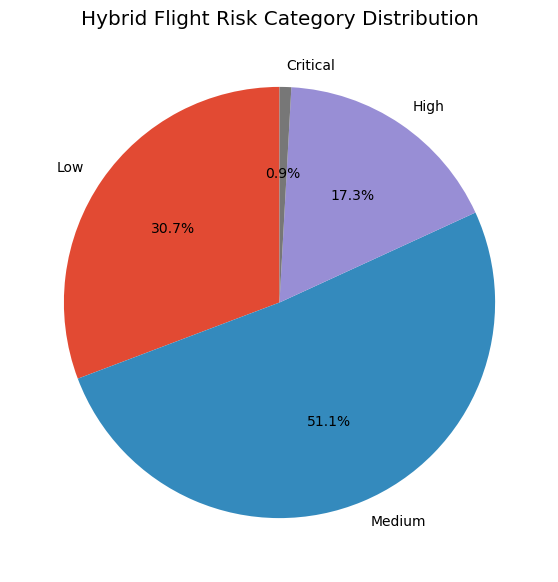

In [79]:
plt.figure(figsize=(7,7))

elm_df["Hybrid_Risk_Category"].value_counts().sort_index().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")

plt.title("Hybrid Flight Risk Category Distribution")

plt.show()

In [73]:
display(

elm_df[
[
"Hybrid_Flight_Risk_Score",
"Hybrid_Risk_Category"
]
].head(10)

)

,Hybrid_Flight_Risk_Score,Hybrid_Risk_Category
0,34.257313,Medium
1,15.932230,Low
2,38.488734,Medium
3,26.026544,Medium
4,38.804378,Medium
5,42.239490,Medium
6,22.891592,Low
7,46.809358,Medium
8,29.495564,Medium
9,17.043546,Low


In [80]:
# ==========================================================
# SECTION 13 - Save Final Hybrid AI Dataset
# ==========================================================

import os

output_path = "../data/final"
os.makedirs(output_path, exist_ok=True)

elm_df.to_csv(
    f"{output_path}/hybrid_ai_risk_assessment.csv",
    index=False
)

print("="*70)
print("Hybrid AI Risk Assessment Dataset Saved Successfully")
print("="*70)
print(f"Shape : {elm_df.shape}")
print(f"Location : {output_path}/hybrid_ai_risk_assessment.csv")

Hybrid AI Risk Assessment Dataset Saved Successfully
Shape : (7516, 94)
Location : ../data/final/hybrid_ai_risk_assessment.csv
